# 🧠 EX49: YOLO Result Analysis & Training Diagnostics

Welcome, students! Today we are exploring the critical process of analyzing training logs to diagnose the learning behavior of YOLO models. When training custom object detectors, you cannot simply let the model run blindly; you must inspect its training dynamics to make informed decisions about hyperparameters, regularization, and model capacity.

## 1. Under the Hood: Loss Functions in Anchor-Free YOLO

Modern YOLO variants (like YOLOv8 and YOLO11) are **Anchor-Free** detectors. Let's contrast this with older anchor-based architectures:
- **Anchor-Based (e.g., YOLOv3, YOLOv4, YOLOv5):** These models rely on predefined bounding box shapes (anchors). The network predicts offsets from these anchors. Mismatched anchors can lead to extremely poor box regression performance, requiring manual anchor clustering beforehand.
- **Anchor-Free (e.g., YOLOv8, YOLO11):** These models predict bounding box boundaries directly from the grid points (distance from point to left, top, right, bottom margins). This makes them much more flexible and robust.

During training, YOLO tracks three primary loss components in `results.csv`:
1. **Box Loss (`train/box_loss`, `val/box_loss`):** Computed using Complete IoU (CIoU) loss. It measures how accurately the predicted bounding box coordinates align with the ground truth.
2. **Classification Loss (`train/cls_loss`, `val/cls_loss`):** Computed using Binary Cross-Entropy (BCE) loss. It measures the classification accuracy for each grid cell.
3. **Distribution Focal Loss (`train/dfl_loss`, `val/dfl_loss`):** In anchor-free models, bounding box coordinates are modeled as continuous probability distributions. DFL helps the model learn the boundary positions relative to target centers more precisely, especially under occlusion or blurred boundaries.

Total Loss is the weighted sum of these three components. We monitor both training and validation losses to assess convergence.

## 2. First-Principles Explanation of Evaluation Metrics

To validate a YOLO model, we use metrics derived from the overlap between predictions and ground truths:

### A. Precision & Recall
- **Precision (P):** Out of all predicted bounding boxes, how many were correct?
  $$\text{Precision} = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Positives (FP)}}$$
  *High precision means few false positives (low false alarm rate).* 

- **Recall (R):** Out of all actual objects in the dataset, how many did the model find?
  $$\text{Recall} = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Negatives (FN)}}$$
  *High recall means few false negatives (very few missed objects).* 

### B. Mean Average Precision (mAP)
Average Precision (AP) is the area under the Precision-Recall curve. Mean Average Precision (mAP) is the average AP across all classes.
- **mAP@0.5 (or mAP50):** The mAP calculated at a fixed Intersection-over-Union (IoU) threshold of $0.5$. If a predicted box overlaps the ground truth by $\ge 50\%$, it's considered correct. This is a lenient metric that checks if the model has found the general location of the object.
- **mAP@0.5:0.95 (or mAP50-95):** The mAP averaged over 10 different IoU thresholds: $0.5, 0.55, 0.6, \dots, 0.95$. This is the primary COCO competition metric. It is much stricter and highly rewards high-quality bounding boxes that match the ground truth coordinates precisely.

In [1]:
# Back up or checkpoint this section of code before starting to modify the large file.
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

def generate_mock_data(output_path: str, mode: str = 'normal', num_epochs: int = 50):
    """
    Generates a mock results.csv file simulating YOLO training outputs.
    """
    epochs = np.arange(1, num_epochs + 1)
    time_per_epoch = 5.0 + np.random.normal(0, 0.2, num_epochs)
    
    train_box = 1.5 * np.exp(-epochs / 15) + 0.1 + np.random.normal(0, 0.01, num_epochs)
    train_cls = 2.0 * np.exp(-epochs / 12) + 0.05 + np.random.normal(0, 0.01, num_epochs)
    train_dfl = 1.0 * np.exp(-epochs / 18) + 0.02 + np.random.normal(0, 0.005, num_epochs)
    
    if mode == 'normal':
        val_box = 1.5 * np.exp(-epochs / 14) + 0.15 + np.random.normal(0, 0.02, num_epochs)
        val_cls = 2.0 * np.exp(-epochs / 11) + 0.1 + np.random.normal(0, 0.02, num_epochs)
        val_dfl = 1.0 * np.exp(-epochs / 16) + 0.04 + np.random.normal(0, 0.01, num_epochs)
        mAP50 = 0.9 * (1.0 - np.exp(-epochs / 8)) + np.random.normal(0, 0.005, num_epochs)
        mAP50_95 = 0.7 * (1.0 - np.exp(-epochs / 9)) + np.random.normal(0, 0.005, num_epochs)
    else:
        val_box = []
        val_cls = []
        val_dfl = []
        mAP50 = []
        mAP50_95 = []
        for e in epochs:
            base_box = 1.5 * np.exp(-e / 14) + 0.15
            base_cls = 2.0 * np.exp(-e / 11) + 0.1
            base_dfl = 1.0 * np.exp(-e / 16) + 0.04
            base_mAP50 = 0.9 * (1.0 - np.exp(-e / 8))
            base_mAP50_95 = 0.7 * (1.0 - np.exp(-e / 9))
            if e > 25:
                drift = 0.03 * (e - 25)
                base_box += drift
                base_cls += drift * 1.5
                base_dfl += drift * 0.5
                base_mAP50 -= 0.005 * (e - 25)
                base_mAP50_95 -= 0.008 * (e - 25)
            val_box.append(base_box + np.random.normal(0, 0.01))
            val_cls.append(base_cls + np.random.normal(0, 0.01))
            val_dfl.append(base_dfl + np.random.normal(0, 0.005))
            mAP50.append(max(0.0, min(1.0, base_mAP50 + np.random.normal(0, 0.005))))
            mAP50_95.append(max(0.0, min(1.0, base_mAP50_95 + np.random.normal(0, 0.005))))
        val_box = np.array(val_box)
        val_cls = np.array(val_cls)
        val_dfl = np.array(val_dfl)
        mAP50 = np.array(mAP50)
        mAP50_95 = np.array(mAP50_95)
        
    precision = 0.85 * mAP50 + np.random.normal(0, 0.01, num_epochs)
    recall = 0.8 * mAP50 + np.random.normal(0, 0.01, num_epochs)
    lr_pg0 = 0.01 * (1.0 - epochs / num_epochs)
    
    df = pd.DataFrame({
        'epoch': epochs,
        'time': time_per_epoch,
        'train/box_loss': train_box,
        'train/cls_loss': train_cls,
        'train/dfl_loss': train_dfl,
        'metrics/precision(B)': precision,
        'metrics/recall(B)': recall,
        'metrics/mAP50(B)': mAP50,
        'metrics/mAP50-95(B)': mAP50_95,
        'val/box_loss': val_box,
        'val/cls_loss': val_cls,
        'val/dfl_loss': val_dfl,
        'lr/pg0': lr_pg0,
        'lr/pg1': lr_pg0,
        'lr/pg2': lr_pg0
    })
    df.to_csv(output_path, index=False)

# Create directories if needed
os.makedirs('runs/detect/train_mock_normal', exist_ok=True)
os.makedirs('runs/detect/train_mock_overfit', exist_ok=True)

normal_path = 'runs/detect/train_mock_normal/results.csv'
overfit_path = 'runs/detect/train_mock_overfit/results.csv'

generate_mock_data(normal_path, mode='normal', num_epochs=45)
generate_mock_data(overfit_path, mode='overfit', num_epochs=45)
print("Mock data generated successfully.")

Mock data generated successfully.


/home/luke/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Analysis functions from solution.py
def check_diagnostics(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    
    # Calculate total training and validation losses
    df['total_train_loss'] = df[['train/box_loss', 'train/cls_loss', 'train/dfl_loss']].sum(axis=1)
    df['total_val_loss'] = df[['val/box_loss', 'val/cls_loss', 'val/dfl_loss']].sum(axis=1)
    
    # Best epoch detection
    best_row_idx = df['metrics/mAP50-95(B)'].idxmax()
    best_epoch = df.loc[best_row_idx, 'epoch']
    best_map = df.loc[best_row_idx, 'metrics/mAP50-95(B)']
    
    # Overfitting check (last 5 epochs)
    recent = df.tail(5)
    epochs = recent['epoch'].values
    train_slope, _ = np.polyfit(epochs, recent['total_train_loss'].values, 1)
    val_slope, _ = np.polyfit(epochs, recent['total_val_loss'].values, 1)
    
    print(f"--- Analysis for {os.path.basename(os.path.dirname(csv_path))} ---")
    print(f"Best Epoch (by mAP50-95): {int(best_epoch)} (Value: {best_map:.4f})")
    print(f"Train loss slope (last 5 epochs): {train_slope:.5f}")
    print(f"Val loss slope (last 5 epochs): {val_slope:.5f}")
    
    if train_slope < -1e-5 and val_slope > 1e-5:
        print("WARNING: Overfitting detected! Train loss is falling, but val loss is rising!")
    else:
        print("No severe overfitting detected in the final epochs.")
    print()

check_diagnostics(normal_path)
check_diagnostics(overfit_path)

--- Analysis for train_mock_normal ---
Best Epoch (by mAP50-95): 40 (Value: 0.6980)
Train loss slope (last 5 epochs): -0.01145
Val loss slope (last 5 epochs): -0.01941
No severe overfitting detected in the final epochs.

--- Analysis for train_mock_overfit ---
Best Epoch (by mAP50-95): 25 (Value: 0.6566)
Train loss slope (last 5 epochs): -0.01063
Val loss slope (last 5 epochs): 0.07553



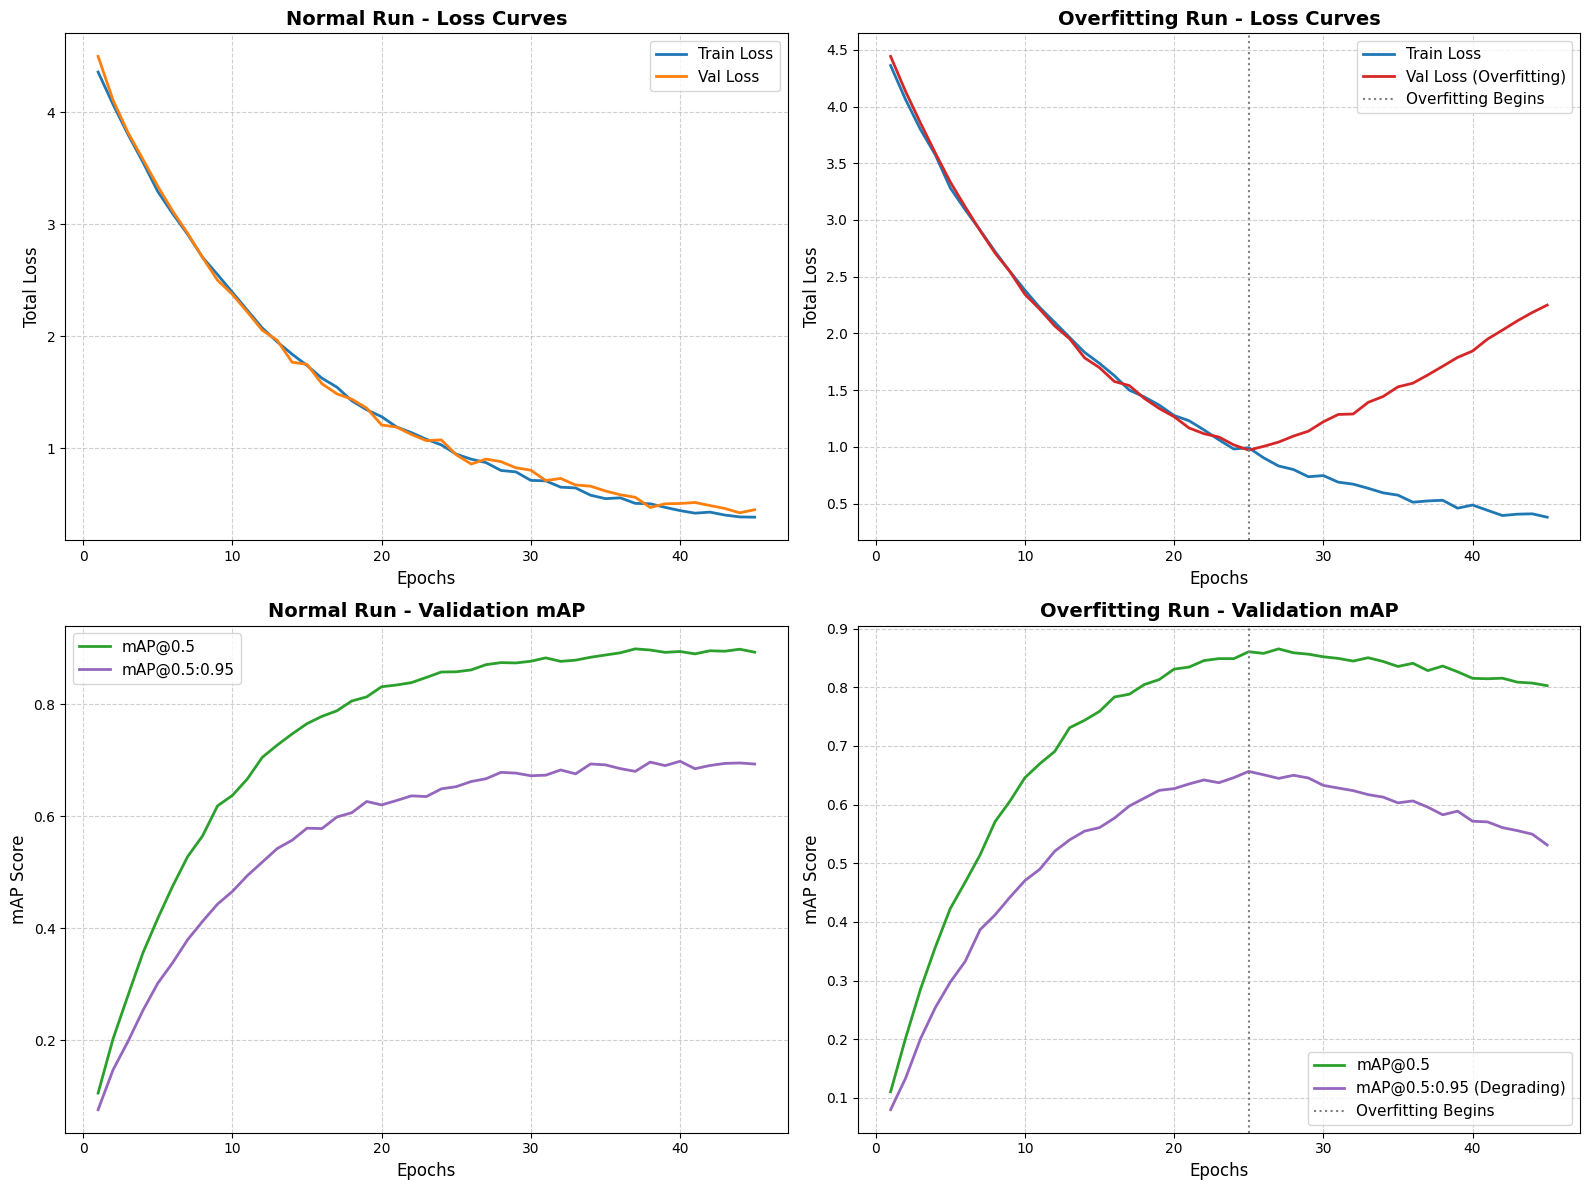

In [3]:
# Plotting the training curves
def plot_training_curves(normal_csv, overfit_csv):
    df_normal = pd.read_csv(normal_csv)
    df_normal.columns = df_normal.columns.str.strip()
    df_normal['total_train_loss'] = df_normal[['train/box_loss', 'train/cls_loss', 'train/dfl_loss']].sum(axis=1)
    df_normal['total_val_loss'] = df_normal[['val/box_loss', 'val/cls_loss', 'val/dfl_loss']].sum(axis=1)
    
    df_overfit = pd.read_csv(overfit_csv)
    df_overfit.columns = df_overfit.columns.str.strip()
    df_overfit['total_train_loss'] = df_overfit[['train/box_loss', 'train/cls_loss', 'train/dfl_loss']].sum(axis=1)
    df_overfit['total_val_loss'] = df_overfit[['val/box_loss', 'val/cls_loss', 'val/dfl_loss']].sum(axis=1)
    
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Normal Run Losses
    axs[0, 0].plot(df_normal['epoch'], df_normal['total_train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
    axs[0, 0].plot(df_normal['epoch'], df_normal['total_val_loss'], label='Val Loss', color='#ff7f0e', linewidth=2)
    axs[0, 0].set_title('Normal Run - Loss Curves', fontsize=14, fontweight='bold')
    axs[0, 0].set_xlabel('Epochs', fontsize=12)
    axs[0, 0].set_ylabel('Total Loss', fontsize=12)
    axs[0, 0].legend(fontsize=11)
    axs[0, 0].grid(True, linestyle='--', alpha=0.6)
    
    # 2. Overfit Run Losses
    axs[0, 1].plot(df_overfit['epoch'], df_overfit['total_train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
    axs[0, 1].plot(df_overfit['epoch'], df_overfit['total_val_loss'], label='Val Loss (Overfitting)', color='#d62728', linewidth=2)
    axs[0, 1].axvline(x=25, color='#7f7f7f', linestyle=':', label='Overfitting Begins')
    axs[0, 1].set_title('Overfitting Run - Loss Curves', fontsize=14, fontweight='bold')
    axs[0, 1].set_xlabel('Epochs', fontsize=12)
    axs[0, 1].set_ylabel('Total Loss', fontsize=12)
    axs[0, 1].legend(fontsize=11)
    axs[0, 1].grid(True, linestyle='--', alpha=0.6)
    
    # 3. Normal Run mAP
    axs[1, 0].plot(df_normal['epoch'], df_normal['metrics/mAP50(B)'], label='mAP@0.5', color='#2ca02c', linewidth=2)
    axs[1, 0].plot(df_normal['epoch'], df_normal['metrics/mAP50-95(B)'], label='mAP@0.5:0.95', color='#9467bd', linewidth=2)
    axs[1, 0].set_title('Normal Run - Validation mAP', fontsize=14, fontweight='bold')
    axs[1, 0].set_xlabel('Epochs', fontsize=12)
    axs[1, 0].set_ylabel('mAP Score', fontsize=12)
    axs[1, 0].legend(fontsize=11)
    axs[1, 0].grid(True, linestyle='--', alpha=0.6)
    
    # 4. Overfit Run mAP
    axs[1, 1].plot(df_overfit['epoch'], df_overfit['metrics/mAP50(B)'], label='mAP@0.5', color='#2ca02c', linewidth=2)
    axs[1, 1].plot(df_overfit['epoch'], df_overfit['metrics/mAP50-95(B)'], label='mAP@0.5:0.95 (Degrading)', color='#9467bd', linewidth=2)
    axs[1, 1].axvline(x=25, color='#7f7f7f', linestyle=':', label='Overfitting Begins')
    axs[1, 1].set_title('Overfitting Run - Validation mAP', fontsize=14, fontweight='bold')
    axs[1, 1].set_xlabel('Epochs', fontsize=12)
    axs[1, 1].set_ylabel('mAP Score', fontsize=12)
    axs[1, 1].legend(fontsize=11)
    axs[1, 1].grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    # Save the output chart to the exercise directory
    plt.savefig('loss_curve_check.png', dpi=300)
    plt.show()

plot_training_curves(normal_path, overfit_path)

## 3. Diagnosing Training Curves

Let's summarize the standard training curve profiles from a Computer Vision engineering perspective:

### 1. Overfitting (Scenario B)
- **What you see:** Training loss continues to fall smoothly, but the validation loss curves hit a minimum and start climbing. Concurrently, validation metrics like `mAP@0.5:0.95` hit a peak and begin to degrade.
- **Why it happens:** The model is memorizing high-frequency features (or noise) specific to the training set rather than learning general patterns. This is typical when the model capacity is too high for the dataset size, or when training is run for too many epochs without enough regularization.
- **Professor's Remedies:**
  - Increase weight decay (`weight_decay=0.0005`).
  - Adjust data augmentations: increase `mosaic` rate, add `mixup`, or utilize `degrees` (rotations).
  - Reduce model size (e.g., scale down from `yolo26s` to `yolo26n`).
  - Enable early stopping (`patience=50` or similar).

### 2. Underfitting
- **What you see:** Both training and validation losses remain high, or converge to an unacceptably high value. Validation mAP metrics flatten out at low levels.
- **Why it happens:** The model lacks the capacity to represent the complexity of the target dataset, or the optimizer is stuck in a poor local minimum.
- **Professor's Remedies:**
  - Use a larger model (e.g., scale up from `yolo26n` to `yolo26s` or `yolo26m`).
  - Decrease regularization (e.g., reduce weight decay or augmentation rates).
  - Increase training duration (`epochs`).
  - Verify learning rate parameters (maybe initial LR `lr0` is too low).

### 3. Plateau (Optimal Convergence / Normal Scenario A)
- **What you see:** Training and validation losses decrease in tandem and flatten out at low levels. Validation mAP climbs steadily and stabilizes, remaining high.
- **Why it happens:** This represents optimal training behavior. The model has learned the generalizeable concepts in the dataset and has converged to a stable minimum.
- **Professor's Action:** Stop training. Export the `weights/best.pt` checkpoint to ONNX or TensorRT for deployment.